In [1]:
import torch
from PIL import Image
import nibabel as nib
from nibabel import filebasedimages
import numpy as np
from typing import Literal
from piqa import SSIM

import sys
sys.path.append("../../datasets/libs/image-utils/src")
from my_io import load_gray_image, print_image
from spatial_transforms import get_bounding_box
from noise import add_rician_noise
from quality_metrics import compute_epi_torch, compute_cnr_torch, psnr_with_mask


In [2]:
def get_volume(
    name: Literal["t1_icbm_normal_1mm_pn0_rf20", "sub48", "sub4"], denoised: bool, std:str='0.10'
):
    if denoised:
        return nib.load(f"../dataset/volumetric_denoised_brains/{name}_{std}.nii.gz")  # type: ignore
    return nib.load(  # type: ignore
        f"../dataset/volumetric_brains/{name}.nii.gz"
    )

def get_mask(n: int):
    return load_gray_image(
        f"../../datasets/dataset/im_{n}/mask.png",
        as_mask=True,
    )

def get_slice(img_array: filebasedimages.FileBasedImage, n: int):
    if n == 1:
        return np.rot90(img_array.get_fdata()[117, :, ::-1])  # type: ignore
    if n == 2:
        return img_array.get_fdata()[90, :, :]  # type: ignore
    if n == 3:
        return img_array.get_fdata()[::-1, 108, :]  # type: ignore
    if n == 4:
        return img_array.get_fdata()[::-1, :, 90]  # type: ignore
    if n == 5:
        return img_array.get_fdata()[107, ::-1, :]  # type: ignore
    if n == 6:
        return img_array.get_fdata()[53, ::-1, :]  # type: ignore
    if n == 7:
        return img_array.get_fdata()[32, ::-1, :]  # type: ignore
    if n == 8:
        return img_array.get_fdata()[80, ::-1, :]  # type: ignore
    if n == 9:
        return np.rot90(img_array.get_fdata()[:, ::-1, 128], k=2)  # type: ignore
    raise Exception(f"Wrong n: {n}")

def pad_to_256(t: torch.Tensor):
    import torch.nn.functional as F

    h, w = t.shape
    pad_h = max(0, 256 - h)
    pad_w = max(0, 256 - w)

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    return F.pad(t, (pad_left, pad_right, pad_top, pad_bottom))


In [3]:
def get_image(n: int, denoised: bool, std: str = '0.10'):
    if n > 1 and n < 9:
        s_denoised = get_slice(get_volume("t1_icbm_normal_1mm_pn0_rf20", denoised, std), n)
        if denoised:
            s_denoised = torch.from_numpy(s_denoised.copy())
            s_denoised = s_denoised.numpy()
        return s_denoised
    if n == 1:
        s_denoised = get_slice(get_volume("sub4", denoised, std), n)
        s_denoised = torch.from_numpy(s_denoised.copy())
        s_denoised = s_denoised.numpy()
        return s_denoised
    if n == 9:
        return get_slice(get_volume("sub48", denoised, std), n)
    raise Exception(f"Wrong n: {n}")


In [3]:
def compute_metrics(gt: torch.Tensor, mask: torch.Tensor, img: torch.Tensor, data_range:float):
    bbox = get_bounding_box(mask)
    res = {}
    ssim=SSIM(n_channels=1, value_range=data_range)
    res["PSNR"] = psnr_with_mask(img, gt, mask, data_range=data_range).item()
    res["SSIM"] = ssim(
        (img * mask)[None, ...][
            ...,
            bbox[0][0] : bbox[1][0],
            bbox[0][1] : bbox[1][1],
        ],
        (gt * mask)[None, ...][
            ...,
            bbox[0][0] : bbox[1][0],
            bbox[0][1] : bbox[1][1],
        ],
    ).item()
    cnr = compute_cnr_torch(img=img, mask=mask) / compute_cnr_torch(img=gt, mask=mask)
    res["CNRI"] = 1 - abs(1 - min(cnr, 1 / cnr))
    res["EPI"] = compute_epi_torch(denoised=img * mask, reference=gt * mask)
    return res

In [ ]:
for std in ['0.10','0.15','0.20','0.25']:
    print(f"--- σ = {std} ---")
    results=[]
    for n in range(1, 10):
        mask = get_mask(n).to(torch.float32)
        gt = get_image(n, denoised=False, std=std)
        gt = pad_to_256(torch.from_numpy(gt.copy()))[None,...]
        gt = gt.to(torch.float32)
        denoised = get_image(n, denoised=True, std=std)
        denoised = pad_to_256(torch.from_numpy(denoised.copy()))[None, ...]
        denoised = denoised.to(torch.float32)
        results += [compute_metrics(gt, mask, denoised/63.75, data_range=gt.max())]
    # print out global metrics
    metrics = {k: np.array([r[k] for r in results]) for k in results[0]}
    summary = {k: {'mean': np.mean(v), 'std': np.std(v)} for k, v in metrics.items()}
    for metric, stats in summary.items():
        mean = stats['mean']
        std = stats['std']
        print(f"   {metric}: mean = {mean:.4f}, std = {std:.4f}")
    # print out per-image metrics
    for i, r in enumerate(results, 1):
        print(f"   Image i_{i}: ", end='')
        print(", ".join(f"{k} = {v:.4f}" for k, v in r.items()))


--- σ = 0.10 ---
   PSNR: mean = 32.2791, std = 1.9075
   SSIM: mean = 0.9228, std = 0.0454
   CNRI: mean = 0.9963, std = 0.0045
   EPI: mean = 0.9608, std = 0.0149
   Image i_1: PSNR = 29.2667, SSIM = 0.8398, CNRI = 0.9914, EPI = 0.9302
   Image i_2: PSNR = 33.1363, SSIM = 0.9589, CNRI = 0.9998, EPI = 0.9740
   Image i_3: PSNR = 33.8940, SSIM = 0.9502, CNRI = 0.9992, EPI = 0.9740
   Image i_4: PSNR = 32.4992, SSIM = 0.9355, CNRI = 0.9981, EPI = 0.9604
   Image i_5: PSNR = 34.5998, SSIM = 0.9636, CNRI = 0.9986, EPI = 0.9706
   Image i_6: PSNR = 32.6495, SSIM = 0.9278, CNRI = 0.9999, EPI = 0.9630
   Image i_7: PSNR = 32.8878, SSIM = 0.9378, CNRI = 0.9957, EPI = 0.9638
   Image i_8: PSNR = 33.0192, SSIM = 0.9508, CNRI = 0.9979, EPI = 0.9721
   Image i_9: PSNR = 28.5590, SSIM = 0.8408, CNRI = 0.9858, EPI = 0.9392
--- σ = 0.15 ---
   PSNR: mean = 30.1031, std = 1.6494
   SSIM: mean = 0.8884, std = 0.0549
   CNRI: mean = 0.9876, std = 0.0182
   EPI: mean = 0.9369, std = 0.0203
   Image i_1:

We print out some images:

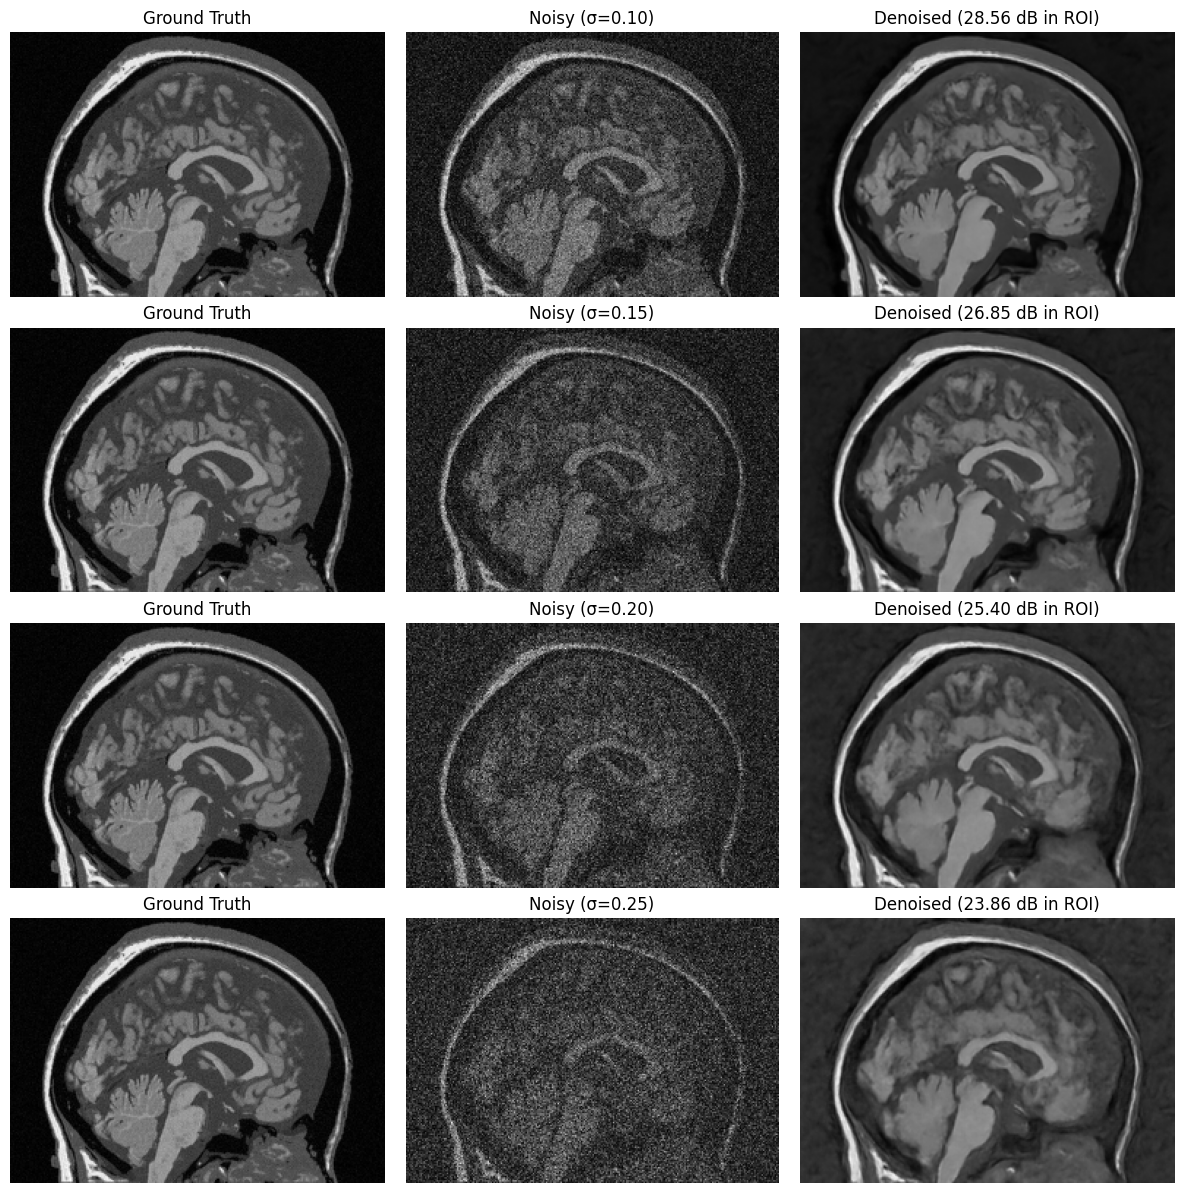

In [6]:
import matplotlib.pyplot as plt 

gt = get_image(9, denoised=False).squeeze()

sigmas = ['0.10', '0.15', '0.20', '0.25']
psnrs=['28.56', '26.85', '25.40', '23.86']
fig, axs = plt.subplots(len(sigmas), 3, figsize=(12, 12))

for i, (sigma, db) in enumerate(zip(sigmas, psnrs)):
    noisy = np.rot90(torch.load(f'../dataset/volumetric_noisy_brains/sub48_noisy_{sigma}.pt').squeeze().numpy()[:, :, 128])
    denoised = get_image(9, denoised=True, std=sigma).squeeze()

    images = [gt, noisy, denoised]
    titles = ['Ground Truth', f'Noisy (σ={sigma})', f'Denoised ({db} dB in ROI)']

    for j in range(3):
        axs[i, j].imshow(images[j], cmap='gray')
        axs[i, j].set_title(titles[j])
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()

In [13]:


gt = get_image(8, denoised=False).squeeze()

sigmas = ['0.10', '0.15', '0.20', '0.25']


for sigma in sigmas:
    
    denoised = get_image(8, denoised=True, std=sigma).squeeze()
    denoised = denoised / denoised.max()
    print_image((denoised*255).squeeze().astype(np.uint8), f'drcnet_im8_{sigma}.png')

In [ ]:
n=8
std='0.15'
gt = get_image(n, denoised=False, std=std)
gt=pad_to_256(torch.from_numpy(gt.copy()))[None,...]
denoised=get_image(n, denoised=True, std=std)
denoised=pad_to_256(torch.from_numpy(denoised.copy()))[None,...]
mask = get_mask(n)

In [ ]:
print(gt.shape,denoised.shape,mask.shape)
print(gt.max(),gt.min())
print(denoised.max()/63.75,denoised.min())
print(mask.min(), mask.max())

torch.Size([1, 256, 256]) torch.Size([1, 256, 256]) torch.Size([1, 256, 256])
tensor(1129.6649, dtype=torch.float64) tensor(0., dtype=torch.float64)
tensor(1118., dtype=torch.float64) tensor(0., dtype=torch.float64)
tensor(0.) tensor(1.)


In [ ]:
compute_metrics(gt.to(torch.float32),mask,(denoised/63.75).to(torch.float32),data_range=gt.max())

{'PSNR': 30.911440900407015,
 'SSIM': 0.922218918800354,
 'CNRI': 0.9933977210595016,
 'EPI': 0.9546682238578796}

In [ ]:
import matplotlib.pyplot as plt 

gt = get_image(9, denoised=False).squeeze()

sigmas = ['0.10', '0.15', '0.20', '0.25']
psnrs=['28.56', '26.85', '25.40', '23.86']
fig, axs = plt.subplots(len(sigmas), 3, figsize=(12, 12))

for i, (sigma, db) in enumerate(zip(sigmas, psnrs)):
    noisy = np.rot90(torch.load(f'../dataset/volumetric_noisy_brains/sub48_noisy_{sigma}.pt').squeeze().numpy()[:, :, 128])
    denoised = get_image(9, denoised=True, std=sigma).squeeze()

    images = [gt, noisy, denoised]
    titles = ['Ground Truth', f'Noisy (σ={sigma})', f'Denoised ({db} dB in ROI)']

    for j in range(3):
        axs[i, j].imshow(images[j], cmap='gray')
        axs[i, j].set_title(titles[j])
        axs[i, j].axis('off')

plt.tight_layout()
plt.show()

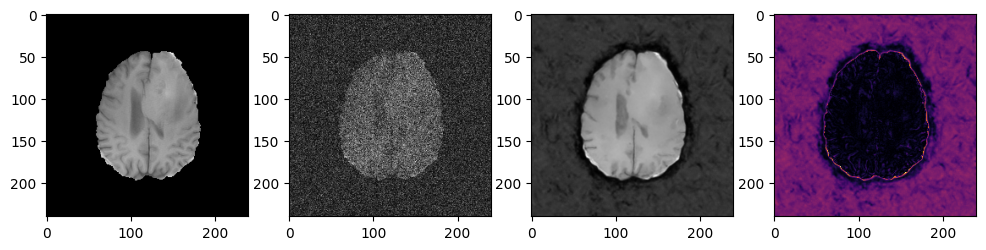

In [5]:
import matplotlib.pyplot as plt
noisy=torch.load('../dataset/volumetric_noisy_brains/BraTS2021_00002_t1_ESESTE_noisy_0.15.pt').squeeze().numpy()[:, :, 100]
dn=np.rot90(nib.load('/mnt/data_drive/hrodrigo/rd-dip-reproducibility/using_DRCnet/dataset/volumetric_denoised_brains/BraTS2021_00002_t1_ESESTE_0.15_test2.nii.gz').get_fdata()[:, ::-1, 100])
gt=np.rot90(nib.load('/mnt/data_drive/hrodrigo/rd-dip-reproducibility/using_DRCnet/dataset/volumetric_brains/BraTS2021_00002_t1_ESESTE.nii.gz').get_fdata()[:, ::-1, 100])
fig, axs = plt.subplots(1, 4, figsize=(12, 12))
axs[0].imshow(gt, cmap='gray')
axs[1].imshow(noisy, cmap='gray')
axs[2].imshow(dn, cmap='gray')
axs[3].imshow(2*np.abs(dn/63.75-gt), cmap='inferno')
plt.show()


In [6]:
print(gt.max()/63.75,noisy.max(),dn.max()/63.75**2)

21.41176470588235 36.85349 19.529411764705884


In [7]:
sqdiff=(gt - dn / 63.75)**2
10*np.log10(gt.max()**2/sqdiff.mean())

np.float64(16.26319746543105)

----

In [31]:
mask=load_gray_image(
        f"../../datasets/dataset/BraTS2021_00002/mask.png",
        as_mask=True,
)

In [37]:
def unpad_image(padded_img: np.ndarray, original_shape: tuple) -> np.ndarray:
    """
    Removes zero-padding from a padded image.

    Args:
        padded_img (np.ndarray): 2D image array with padding.
        original_shape (tuple): (original_height, original_width) before padding.

    Returns:
        np.ndarray: Cropped image with original dimensions.
    """
    orig_h, orig_w = original_shape
    pad_h = padded_img.shape[0] - orig_h
    pad_w = padded_img.shape[1] - orig_w
    pad_top = pad_h // 2
    pad_left = pad_w // 2
    return padded_img[pad_top:pad_top+orig_h, pad_left:pad_left+orig_w]


In [9]:
import matplotlib.pyplot as plt

dn=np.rot90(nib.load('/mnt/data_drive/hrodrigo/rd-dip-reproducibility/using_DRCnet/dataset/volumetric_denoised_brains/BraTS2021_00002_t1_ESESTE_0.15_test2.nii.gz').get_fdata()[:, ::-1, 100])
dn = torch.from_numpy(dn.copy())[None,...].to(torch.float32)
gt=np.rot90(nib.load('/mnt/data_drive/hrodrigo/rd-dip-reproducibility/using_DRCnet/dataset/volumetric_brains/BraTS2021_00002_t1_ESESTE.nii.gz').get_fdata()[:, ::-1, 100])
gt = torch.from_numpy(gt.copy())[None,...].to(torch.float32)
mask=load_gray_image(
        f"../../datasets/dataset/BraTS2021_00002/mask.png",
        as_mask=True,
)
mask=mask[..., 8:-8,8:-8]

In [10]:
mask.shape

torch.Size([1, 240, 240])

In [11]:
print(mask.dtype, gt.dtype, dn.dtype)
print(mask.shape, gt.shape, dn.shape)

torch.float32 torch.float32 torch.float32
torch.Size([1, 240, 240]) torch.Size([1, 240, 240]) torch.Size([1, 240, 240])


In [12]:
compute_metrics(gt,mask, dn/63.75, data_range=gt.max())

{'PSNR': 28.64080047607422,
 'SSIM': 0.8343982696533203,
 'CNRI': 7.446054883786246e-11,
 'EPI': 0.9622920751571655}

/tmp/ipykernel_2196201/2471522842.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  axs[3].imshow(2*np.abs(dn/63.75-gt).squeeze(), cmap='inferno')


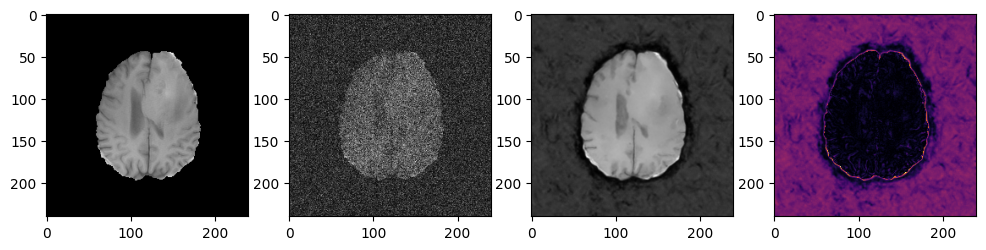

In [52]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(12, 12))
axs[0].imshow(gt.squeeze(), cmap='gray')
axs[1].imshow(noisy.squeeze(), cmap='gray')
axs[2].imshow(dn.squeeze(), cmap='gray')
axs[3].imshow(2*np.abs(dn/63.75-gt).squeeze(), cmap='inferno')
plt.show()


----

In [2]:
noisy=torch.load('../dataset/volumetric_noisy_brains/knee_noisy_0.15.pt').squeeze().numpy()

In [3]:
noisy.shape

(512, 512, 34)

In [8]:
def pad_to_512(t: torch.Tensor):
    import torch.nn.functional as F

    h, w = t.shape[-2:]
    pad_h = max(0, 512 - h)
    pad_w = max(0, 512 - w)

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    return F.pad(t, (pad_left, pad_right, pad_top, pad_bottom))

In [27]:
import matplotlib.pyplot as plt
from my_io import print_image
gt=torch.from_numpy(np.rot90(nib.load('/mnt/data_drive/hrodrigo/rd-dip-reproducibility/using_DRCnet/dataset/volumetric_brains/knee.nii.gz').get_fdata()[:,:,17]).copy())
gt=gt.to(torch.float32)
for std in ['0.10','0.15','0.20','0.25']:
    print(f"--- σ = {std} ---")
    results=[]
    n='knee'
    mask = 1+0*pad_to_512(get_mask(1).to(torch.float32))
    dn=torch.from_numpy(np.rot90(nib.load(f'/mnt/data_drive/hrodrigo/rd-dip-reproducibility/using_DRCnet/dataset/volumetric_denoised_brains/knee_{std}_test2.nii.gz').get_fdata()[:,:,17]).copy())
    dn=dn.to(torch.float32)/63.75
    print_image(img=(255*(((dn-dn.min())/(dn.max()-dn.min())))).numpy().astype(np.uint8), file_name=f'denoised_{std}.png')
    results += [compute_metrics(gt, mask, dn.clip(0,gt.max()),data_range=gt.max())]
    ## print out global metrics
    metrics = {k: np.array([r[k] for r in results]) for k in results[0]}
    summary = {k: {'mean': np.mean(v), 'std': np.std(v)} for k, v in metrics.items()}
    for metric, stats in summary.items():
        mean = stats['mean']
        std = stats['std']
        print(f"   {metric}: mean = {mean:.4f}, std = {std:.4f}")
    ## print out per-image metrics
    # for i, r in enumerate(results, 1):
    #     print(f"   Image i_{i}: ", end='')
    #     print(", ".join(f"{k} = {v:.4f}" for k, v in r.items()))

--- σ = 0.10 ---


/mnt/data_drive/hrodrigo/rd-dip-reproducibility/using_DRCnet/src/../../datasets/libs/image-utils/src/quality_metrics.py:86: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  sigma_bkg = outside_roi.std()


   PSNR: mean = 25.9116, std = 0.0000
   SSIM: mean = 0.5117, std = 0.0000
   CNRI: mean = nan, std = nan
   EPI: mean = 0.8324, std = 0.0000
--- σ = 0.15 ---
   PSNR: mean = 24.5466, std = 0.0000
   SSIM: mean = 0.4564, std = 0.0000
   CNRI: mean = nan, std = nan
   EPI: mean = 0.7955, std = 0.0000
--- σ = 0.20 ---
   PSNR: mean = 22.8944, std = 0.0000
   SSIM: mean = 0.3873, std = 0.0000
   CNRI: mean = nan, std = nan
   EPI: mean = 0.7430, std = 0.0000
--- σ = 0.25 ---
   PSNR: mean = 16.4777, std = 0.0000
   SSIM: mean = 0.2914, std = 0.0000
   CNRI: mean = nan, std = nan
   EPI: mean = 0.6934, std = 0.0000


In [6]:
import matplotlib.pyplot as plt
from my_io import print_image
gt=torch.from_numpy(np.rot90(nib.load('/mnt/data_drive/hrodrigo/rd-dip-reproducibility/using_DRCnet/dataset/volumetric_brains/abdominal.nii.gz').get_fdata()[::-1,:,34]).copy())
gt=gt.to(torch.float32)
for std in ['0.10','0.15','0.20','0.25']:
    print(f"--- σ = {std} ---")
    results=[]
    n='abdominal'
    mask = (1+0*gt)[None,...]
    dn=torch.from_numpy(np.rot90(nib.load(f'/mnt/data_drive/hrodrigo/rd-dip-reproducibility/using_DRCnet/dataset/volumetric_denoised_brains/abdominal_{std}_test2.nii.gz').get_fdata()[::-1,:,34]).copy())
    dn=dn.to(torch.float32)/63.75
    print_image(img=(255*(((dn-dn.min())/(dn.max()-dn.min())))).numpy().astype(np.uint8), file_name=f'denoised_{std}_abdominal.png')
    results += [compute_metrics(gt, mask, dn.clip(0,gt.max()),data_range=gt.max())]
    ## print out global metrics
    metrics = {k: np.array([r[k] for r in results]) for k in results[0]}
    summary = {k: {'mean': np.mean(v), 'std': np.std(v)} for k, v in metrics.items()}
    for metric, stats in summary.items():
        mean = stats['mean']
        std = stats['std']
        print(f"   {metric}: mean = {mean:.4f}, std = {std:.4f}")
    ## print out per-image metrics
    # for i, r in enumerate(results, 1):
    #     print(f"   Image i_{i}: ", end='')
    #     print(", ".join(f"{k} = {v:.4f}" for k, v in r.items()))

--- σ = 0.10 ---
   PSNR: mean = 29.8985, std = 0.0000
   SSIM: mean = 0.8728, std = 0.0000
   CNRI: mean = nan, std = nan
   EPI: mean = 0.9491, std = 0.0000
--- σ = 0.15 ---


/mnt/data_drive/hrodrigo/rd-dip-reproducibility/using_DRCnet/src/../../datasets/libs/image-utils/src/quality_metrics.py:86: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  sigma_bkg = outside_roi.std()


   PSNR: mean = 27.7584, std = 0.0000
   SSIM: mean = 0.8369, std = 0.0000
   CNRI: mean = nan, std = nan
   EPI: mean = 0.9273, std = 0.0000
--- σ = 0.20 ---
   PSNR: mean = 25.8619, std = 0.0000
   SSIM: mean = 0.7978, std = 0.0000
   CNRI: mean = nan, std = nan
   EPI: mean = 0.9012, std = 0.0000
--- σ = 0.25 ---
   PSNR: mean = 24.7529, std = 0.0000
   SSIM: mean = 0.7663, std = 0.0000
   CNRI: mean = nan, std = nan
   EPI: mean = 0.8746, std = 0.0000


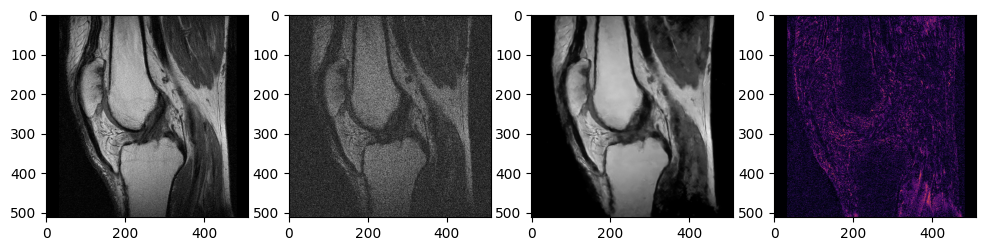

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import nibabel as nib
noisy=torch.load('../dataset/volumetric_noisy_brains/knee_noisy_0.15.pt').squeeze().numpy()[::-1, :, 17]
dn=np.rot90(nib.load('/mnt/data_drive/hrodrigo/rd-dip-reproducibility/using_DRCnet/dataset/volumetric_denoised_brains/knee_0.15_test2.nii.gz').get_fdata()[:,:,17])
gt=np.rot90(nib.load('/mnt/data_drive/hrodrigo/rd-dip-reproducibility/using_DRCnet/dataset/volumetric_brains/knee.nii.gz').get_fdata()[:,:,17])
fig, axs = plt.subplots(1, 4, figsize=(12, 12))
axs[0].imshow(gt, cmap='gray')
axs[1].imshow(noisy, cmap='gray')
axs[2].imshow(dn/63.75, cmap='gray')
axs[3].imshow(2*np.abs(dn/63.75-gt), cmap='inferno')
plt.show()


In [2]:
sqdiff=(gt - dn / 63.75)**2
10*np.log10(gt.max()**2/sqdiff.mean())

np.float64(24.546618553003228)